In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
# import statsmodels.formula.api as smf
# from itertools import combinations
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor



2. a report (as a pdf file) that summarizes the process you followed for reconstructing and
analyzing the data. The report should not contain any code, but it should have a
snapshot of the reconstructed data, appropriate summary plots, and other metrics used in
your analysis and decision making process. The report should include: (i) an introduction
section, (ii) the data cleaning process, (iii) the methodology/approach you took to analyze
the data and perform model selection and (iv) all appropriate results. Finally, the report
should end with a conclusion where you summarize your findings. The report should be
around 5 pages long

    For this task, we are given several parameters about Bitcoin trading on a certain date, and tasked with predicting the Bitcoin market price for the next day. \
    Here are all the recorded metrics:
        Date
        btc_market_price
        btc_total_bitcoins
        btc_market_cap
        btc_trade_volume
        btc_blocks_size
        btc_avg_block_size
        btc_n_orphaned_blocks
        btc_n_transactions_per_block
        btc_median_confirmation_time
        btc_hash_rate
        btc_difficulty
        btc_miners_revenue
        btc_transaction_fees
        btc_cost_per_transaction_percent
        btc_cost_per_transaction
        btc_n_unique_addresses
        btc_n_transactions
        btc_n_transactions_total
        btc_n_transactions_excluding_popular
        btc_n_transactions_excluding_chains_longer_than_100
        btc_output_volume
        btc_estimated_transaction_volume
        btc_estimated_transaction_volume_usd

    Starting off, I'm noticing that many of the metrics do not start until 2010-08-16. 
        These metrics are:
            btc_market_price
            btc_market_cap
            btc_estimated_transaction_volume_usd
    I'm also noticing that Btc_orphaned_blocks seems to be 0.0 throughout, so I will drop that column for ease. \
    Since Bitcoin pre-2011 was not really "of interest" I suppose, I'll go ahead and drop the datapoints up until 2010-08-17


    2010-08-16 00:00:00,0.0,3737700.0,0.0,643.8882,1.0,0.000754655172414,0.0,1.0,0.0,0.00295108644376,511.773534257,0.0,0.0,31.6323664555,0.0,387.0,318.0,104456.0,318.0,318.0,41918.88,18336.0,0.0
    2010-08-17 00:00:00,0.0769,3744250.0,287932.825,923.0018,1.0,0.000958648854962,0.0,1.0,0.0,0.00333269244941,511.773534257,503.695,0.67,13.5678886397,1.43095170455,393.0,352.0,104808.0,352.0,352.0,72855.15,48276.0,3712.0

In [ ]:
# Okay, I think I'll split the first 3 days as training and then use the rest at testing? 
# My main thinking here is that there are a ton of relevant "predictors", so I'll use Lasso regression to disable some of them
# https://scikit-learn.org/stable/modules/impute.html handling missing values by using the mean values
data = pd.read_csv("_5acbed1925f148fe950aa47000a74f15_bitcoin.csv", delimiter=",")
data["Date"] = pd.to_datetime(data["Date"])
# clue: (If your algorithms do not run, consider using 2 or 3 days.)
# I originally did a simple linear regression using the date as a predictor but I think it was kind of bad
# y is the btc_market_price. 
# print(newData.head())
# add the previous days' predictors to the current day. 
def make_lagged_predictors(df, lag = 2, future = 1):
    df = df.copy()
    for i in range(1, lag + 1):
        for col in df.columns:
            if col != "Date":
                df[f"{col}_lag{i}"] = df[col].shift(i)
                # includes "today's data, plus all the lag days"
    df["btc_market_price_y"] = df["btc_market_price"].shift(-future)
    # Since we wouldn't have the transaction volume of the day without the price
    # we should be predicting "tomorrow's" prices
    df = df.dropna().reset_index(drop=True) # I don't want to deal with nans 
    return df

# testing with an arbitrary split

data.drop(columns=["btc_n_orphaned_blocks","btc_estimated_transaction_volume_usd","btc_avg_block_size","btc_difficulty"], inplace=True)
newData = data[data["Date"] > "2010-08-16"]
train = newData[newData["Date"].between("2015-01-01","2015-12-31")]
test  = newData[newData["Date"].between("2016-01-01","2016-12-31")]

# print(test.head())
# train = newData[(newData["Date"] < "2019-01-01") and (newData["Date"] > "2018-01-01")]
# test = newData[(newData["Date"] > "2019-01-01") and (newData["Date"] < "2020-01-01")]

train = make_lagged_predictors(train, lag = 2, future = 1)
test = make_lagged_predictors(test, lag = 2, future = 1)
train_x = train.drop(columns = ["Date","btc_market_price_y"])
train_y = train["btc_market_price_y"]
test_x = test.drop(columns = ["Date","btc_market_price_y"])
test_y = test["btc_market_price_y"]


# print(train_x.head())
# print(test.head())

# needed for LASSO, otherwise coefficients for a regular linear would work fine
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
test_x_scaled = scaler.transform(test_x)
'''
VIFCheck = pd.DataFrame(train_x, columns=train_x.columns)
vif_data = pd.DataFrame()
vif_data["feature"] = VIFCheck.columns
vif_data["VIF"] = [variance_inflation_factor(VIFCheck.values, i) 
                   for i in range(VIFCheck.shape[1])]
vif_data.to_csv('output')
print(vif_data)
'''

'\nVIFCheck = pd.DataFrame(train_x, columns=train_x.columns)\nvif_data = pd.DataFrame()\nvif_data["feature"] = VIFCheck.columns\nvif_data["VIF"] = [variance_inflation_factor(VIFCheck.values, i) \n                   for i in range(VIFCheck.shape[1])]\nvif_data.to_csv(\'output\')\nprint(vif_data)\n'

In [22]:
r_alphas = np.logspace(-5,3,100)
lasso = LassoCV(alphas=r_alphas, cv=5, max_iter=100000)
lasso_model = lasso.fit(train_x_scaled, train_y)
# print("Best lambda (Lasso):", lasso_model.alpha_)
# print("Lasso coefficients:", lasso_model.coef_)



e:\Stuff\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.169e+02, tolerance: 1.146e+02
  model = cd_fast.enet_coordinate_descent_gram(
e:\Stuff\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.167e+02, tolerance: 1.146e+02
  model = cd_fast.enet_coordinate_descent_gram(
e:\Stuff\Program Files\Python\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality

In [23]:
coefficients = lasso_model.coef_
print("Lasso coefficients:", lasso_model.coef_)

coef_df = pd.DataFrame([coefficients], columns=train_x.columns)
# print(coef_df)
zero = coef_df.loc[:, coef_df.iloc[0] == 0]
print("Features dropped:", list(zero.columns))
print(len(list(zero.columns)))
nonzero = coef_df.loc[:, coef_df.iloc[0] != 0]
print("Features dropped:", list(nonzero.columns))
print(len(list(nonzero.columns)))


Lasso coefficients: [ 5.16568767e+01 -5.43600972e-01  0.00000000e+00  3.64881344e-01
 -0.00000000e+00 -0.00000000e+00 -0.00000000e+00  0.00000000e+00
  3.42107893e+00 -1.59565441e+00  0.00000000e+00  2.62444685e-01
  1.37292391e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
 -2.01404728e-02 -1.31864619e+00  7.80155698e-01 -0.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -3.71336309e-01 -0.00000000e+00
  0.00000000e+00  6.91957919e-01  9.53662462e-01 -0.00000000e+00
 -2.03932569e-01 -0.00000000e+00 -3.57554085e-01  0.00000000e+00
  1.46162265e-01 -0.00000000e+00  0.00000000e+00  0.00000000e+00
 -0.00000000e+00 -0.00000000e+00  0.00000000e+00 -0.00000000e+00
  0.00000000e+00 -0.00000000e+00 -0.00000000e+00  3.57287785e-01
 -7.84811305e-01  0.00000000e+00  0.00000000e+00  6.79832442e-01
 -3.17466380e-01 -0.00000000e+00 -2.13522921e-01  0.00000000e+00
 -0.00000000e+00  0.00000000e+00 -0.00000000e+00 -0.00000000e+00
  2.99913452e-01  0.00000000e+00 -0.00000000e+00  0.00000000e+00
  5.8

In [24]:
pred_y = lasso_model.predict(test_x_scaled)
print(f"Lasso MSE: {metrics.mean_squared_error(test_y, pred_y)}")
r2 = metrics.r2_score(test_y, pred_y)
print(f"Model R2: {r2}")
p = len(list(nonzero.columns))
n = len(test_y)
print(p)
print(n)
rss = np.sum(np.square(test_y - pred_y))
aic = n * np.log(rss/n) + (2 * p)
bic = n * np.log(rss/n) + (p * np.log(n))
print(f"Model AIC: {aic}")
print(f"Model BIC: {bic}")


Lasso MSE: 433.9996585597917
Model R2: 0.9772245396871986
28
362
Model AIC: 2254.441836548485
Model BIC: 2363.4078744796066


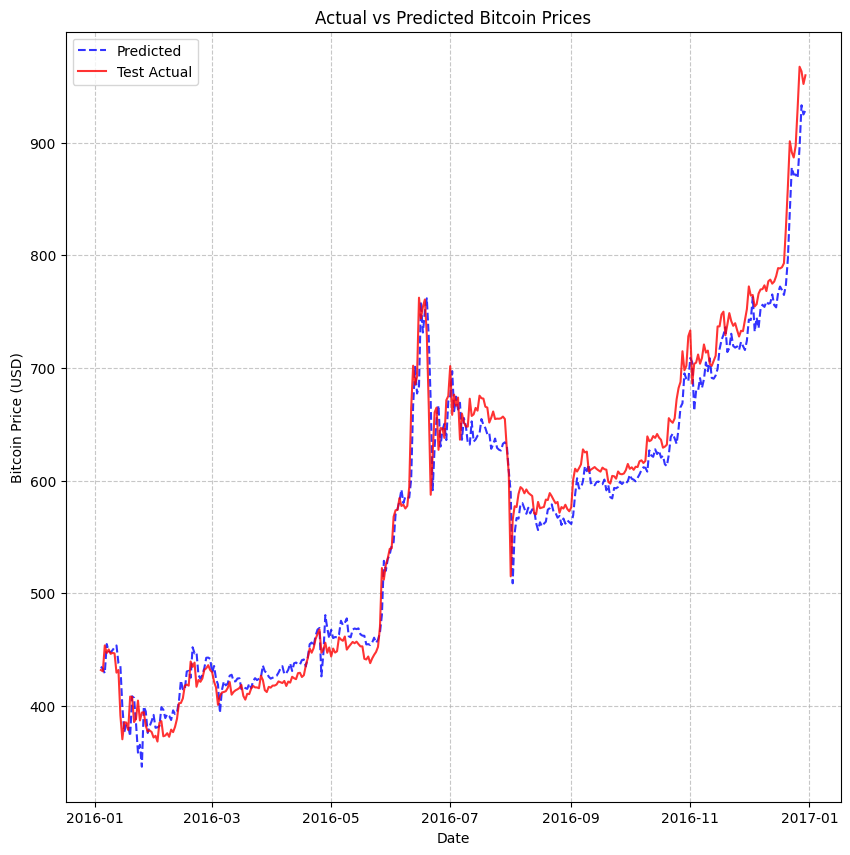

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

# Plot actual prices
# plt.plot(train["Date"], train["Price"], label="Train Actual", color="blue", alpha=0.6)
plt.plot(test["Date"], pred_y, label="Predicted", color="blue", linestyle="--", alpha = 0.8)
plt.plot(test["Date"], test_y, label="Test Actual", color="red", alpha = 0.8)
# Plot predictions
# Formatting
plt.xlabel("Date")
plt.ylabel("Bitcoin Price (USD)")
plt.title("Actual vs Predicted Bitcoin Prices")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig('prediction.png') 
plt.show()

In [26]:
# Baseline

linreg = LinearRegression()
linreg.fit(train_x, train_y)
pred_y2 = linreg.predict(test_x)
print(f"OLS MSE: {metrics.mean_squared_error(test_y, pred_y2)}")
p2 = len(train_x.columns)
rss2 = np.sum(np.square(test_y - pred_y2))
aic = n * np.log(rss2/n) + (2 * p2)
bic = n * np.log(rss2/n) + (p2 * np.log(n))
print(f"Linear AIC: {aic}")
print(f"Linear BIC: {bic}") 



OLS MSE: 2053.03802248275
Linear AIC: 2913.0014893014763
Linear BIC: 3208.766449400235
